# 06 Assess Pooled vs Sample called inversions
We also want to understand how effective the sample-pooling strategy is for detecting inversions, particularly as depth decreases. This process uses the same data as the previous SV assessment, but investigates the data a little differently. It's separated out into its own
notebook for ease of reading. The beginning of this notebook (preparing the data) is a shorthand that is otherwise identical to the general assessment and the new analyses begin with `Pooled vs Sample`.

In [61]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(viridis)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)

Loading required package: viridisLite



In [88]:
read_truth_data <- function(size_treatment){
    truthfile <- paste0("simulated_variants/inversions_genomes/", size_treatment, "/inv.", size_treatment,".vcf")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$size <- size_treatment
    true_inversions <- group_by(true_inversions, contig) %>%
        mutate(id = 1:n())
    return(true_inversions[, c("contig", "id","size","position_start", "position_end")])
}

read_called_data <- function(size_treatment){
    called_df <- data.frame(
        sample = character(),
        contig = character(),
        size = character(),
        depth = character(),
        position_start = numeric(),
        position_end = numeric()
    )
    for(depth in c(0.5, 2, 5, 10, 20)){
        .depth <- paste("depth", depth, sep = "_")
        samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_sample90/inversions.bedpe", sep = "/")
        poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_pop90/inversions.bedpe", sep = "/")

        sample_inversions <- read.table(
            samplesfile,
            header = T
        )[,1:4]
        if( nrow(sample_inversions) > 0){
            sample_inversions$size <- size_treatment
            sample_inversions$depth <- depth
            sample_inversions$sample <- gsub(pattern = "\\..*X", "", sample_inversions$sample)
        } else {
            sample_inversions$size <- character()
            sample_inversions$depth <- character()
        }

        pooled_inversions <- read.table(poolfile, header = T)
        pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
        names(pooled_inversions)[1] <- "sample"
        if( nrow(pooled_inversions) > 0){
            pooled_inversions$sample <- "pooled"
            pooled_inversions$size <- size_treatment
            pooled_inversions$depth <- depth
        } else {
            pooled_inversions$size <- character()
            pooled_inversions$depth <- character()
        }
        called_df <- rbind(called_df, sample_inversions, pooled_inversions)
    }

    return(called_df)
}

## Read in data
The assessment process is a little tricky, so let's start by having one dataframe of the known inversions and another of the called inversions. Using `Reduce(rbind, Map())` is going to make life a lot easier here.

In [91]:
# known variants
truthset <- data.frame(Reduce(rbind, Map(read_truth_data, c("small","medium","large","xl"))))
# called variants
calledset <- data.frame(Reduce(rbind, Map(read_called_data, c("small","medium","large","xl"))))

# variant inventory
inv_inventory <- read.table("inversion_simulations.inventory", header = T)
names(inv_inventory)[4] <- "id"
## add pooled samples
pool_inventory <- read.table("inversion_simulations.pool.inventory", header = T)
names(pool_inventory)[4] <- "id"
inv_inventory <- rbind(inv_inventory, pool_inventory)
inv_inventory <- left_join(inv_inventory, truthset, by = c("contig","id", "size"))

head(inv_inventory)

,sample,size,contig,id,present,state,position_start,position_end
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>
1,sample_01,small,2R,1,TRUE,het,4328632,4333509
2,sample_01,small,2R,2,TRUE,het,9952840,9959287
3,sample_01,small,2R,3,TRUE,het,10569437,10578078
4,sample_01,small,2R,4,TRUE,het,11083686,11094907
5,sample_01,small,2R,5,TRUE,het,21736723,21759355
6,sample_02,small,2R,1,TRUE,het,4328632,4333509


## Match called and known inversions

Next comes what should be a big loop that goes through rows of `inv_inventory` (an inversion for a sample) and checks `calledset` for if that inversion was called. We will need a nested loop that (outer loop) iterates through the depth treatments and an inner loop that iterates through the big inventory manifest (`inv_inventory`).

So now we loop through `inv_inventory` and try to match calls in `calledset`, adjusting the `count` column as necessary (booleans are easy to sum)

- check the `callset` for that inversion on that contig in that sample at that depth
  - if `inv_inventory$present` is `TRUE`, then and it **is** there, it's a TRUE POSITIVE
  - if `inv_inventory$present` is `TRUE`, then and it's **not** there, it's a FALSE NEGATIVE
  - if `inv_inventory$present` is `FALSE`, then and it **is** there, it's a FALSE POSITIVE
  - if `inv_inventory$present` is `FALSE`, then and it's **not** there, it's a TRUE NEGATIVE

all while doing a fuzzy match of 1 kbp

The `is_called()` function below will do all that. It takes a row from `inv_inventory` as input and will try to fuzzy-match the known inversion in the set of called inversions (`calledset`). One row goes in, but four rows get outputted (one row each for True/False Positive/Negative), and the resulting 4-row dataframe will be appended onto a growing results dataframe `assessment`. This 1-to-4 conversion makes the resulting dataframe in long-format, which will make math and plotting easier.

In [92]:
assessment <- data.frame(
    sample = character(),
    size = character(),
    contig = character(),
    id = integer(),
    present = logical(),
    state = character(),
    position_start = integer(),
    position_end = integer(),
    depth = character(),
    assessment = character(),
    count = logical()
)

In [ ]:
is_called2 <- function(truth_row, called_sv, depth_treatment, fuzzy_distance){
    # the vector returned corresponds to c(TP, FP, TN, FN)
    samplename <- truth_row$sample
    sizeclass <- truth_row$size
    # add padding to make the breakpoints more generous
    fuzzy_start <- truth_row$position_start - fuzzy_distance
    fuzzy_end <- truth_row$position_end + fuzzy_distance
    q_contig <- truth_row$contig
    present <- truth_row$present
    filtered_called <- filter(
        called_sv,
        sample == samplename,
        contig == q_contig,
        size == sizeclass,
        depth == depth_treatment,
        position_start >= fuzzy_start,
        position_end <= fuzzy_end
    )
    if nrow(filtered_called
    return(filtered_called)
}

In [115]:
head(calledset[calledset$depth == 20,])

,sample,contig,position_start,position_end,size,depth
,<chr>,<chr>,<int>,<int>,<chr>,<dbl>
334,sample_10,2L,3193195,3214220,small,20
335,sample_10,2L,3940210,3944863,small,20
336,sample_10,2L,13024403,13026576,small,20
337,sample_10,2L,14845708,14861200,small,20
338,sample_10,2L,20107900,20113695,small,20
339,sample_10,2R,9952839,9959287,small,20


In [121]:
inv_inventory[2,]
is_called2(inv_inventory[2,], calledset, 20 , 1000)

,sample,size,contig,id,present,state,position_start,position_end
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>
2,sample_01,small,2R,2,TRUE,het,9952840,9959287


sample,contig,position_start,position_end,size,depth
<chr>,<chr>,<int>,<int>,<chr>,<dbl>
sample_01,2R,9952839,9959287,small,20


In [12]:
is_called <- function(query_row, called_sv, depth_treatment, fuzzy_distance){
    # the vector returned corresponds to c(TP, FP, TN, FN)
    samplename <- query_row$sample
    sizeclass <- query_row$size
    # add padding to make the breakpoints more generous
    fuzzy_start <- query_row$position_start - fuzzy_distance
    fuzzy_end <- query_row$position_end + fuzzy_distance
    q_contig <- query_row$contig
    present <- query_row$present
    filtered_called <- filter(
        called_sv,
        sample == samplename,
        contig == q_contig,
        size == sizeclass,
        depth == depth_treatment,
        position_start >= fuzzy_start,
        position_end <= fuzzy_end
    )
    hits <- nrow(filtered_called)
    check_vec <- c(FALSE, FALSE, FALSE, FALSE)
    if(present){
        if(hits > 0){
            check_vec[1] <- TRUE
        } else {
            check_vec[4] <- TRUE
        }
    } else {
        if(hits > 0){
            check_vec[2] <- TRUE
        } else {
            check_vec[3] <- TRUE
        }
    }
    out_rows <- query_row[rep(1,4), ]
    out_rows$depth <- depth_treatment
    out_rows$assessment <- c("True Positive", "False Positive", "True Negative", "False Negative")
    out_rows$count <- check_vec
    return(out_rows)
}

In [26]:
depths <- c(0.5, 2.0, 5.0, 10.0, 20.0)
assessment <- data.frame(
    sample = character(),
    size = character(),
    contig = character(),
    id = integer(),
    present = logical(),
    state = character(),
    position_start = integer(),
    position_end = integer(),
    depth = character(),
    assessment = character(),
    count = logical()
)
for(.depth in depths){
    for(i in 1:nrow(inv_inventory)){
        results <- is_called(inv_inventory[i,], calledset, .depth , 1000)
        assessment <- rbind(assessment, results)
    }
}

In [28]:
assessment$depth <- factor(assessment$depth, levels = depths)
assessment$size <- factor(assessment$size, levels = c("small", "medium", "large", "xl"))
# fix pooled-sample state to hom to avoid NA
assessment$state[is.na(assessment$state)] <- "hom"
assessment$type <- factor(if_else(assessment$sample =="pool",true = "pool", false = "sample"))
head(assessment)

,sample,size,contig,id,present,state,position_start,position_end,depth,assessment,count,type
,<chr>,<fct>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>,<fct>,<chr>,<lgl>,<fct>
1,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,True Positive,FALSE,sample
1.1,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,False Positive,FALSE,sample
1.2,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,True Negative,FALSE,sample
1.3,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,False Negative,TRUE,sample
2,sample_01,small,2R,2,TRUE,het,9952840,9959287,0.5,True Positive,FALSE,sample
2.1,sample_01,small,2R,2,TRUE,het,9952840,9959287,0.5,False Positive,FALSE,sample


## Pooling vs Sample
In order to examine how successful pooling or single-sample calling was, we need to account for two things:
1. Pools have every variant represented, albeit in different "quantities" (i.e. the presence/absence and zygotic state of inversions varies between individuals, so some will have more representation than others). It's possible that the number of samples contributing an inversion matters.
2. Single-samples don't all necessarily have every inversion, so we need to be mindful in how we count false negatives.



In [41]:
assessment_present <- filter(assessment, present, assessment == "True Positive")
head(assessment_present)

,sample,size,contig,id,present,state,position_start,position_end,depth,assessment,count,type
,<chr>,<fct>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>,<fct>,<chr>,<lgl>,<fct>
1,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,True Positive,FALSE,sample
2,sample_01,small,2R,2,TRUE,het,9952840,9959287,0.5,True Positive,FALSE,sample
3,sample_01,small,2R,3,TRUE,het,10569437,10578078,0.5,True Positive,FALSE,sample
4,sample_01,small,2R,4,TRUE,het,11083686,11094907,0.5,True Positive,FALSE,sample
5,sample_01,small,2R,5,TRUE,het,21736723,21759355,0.5,True Positive,FALSE,sample
6,sample_02,small,2R,1,TRUE,het,4328632,4333509,0.5,True Positive,FALSE,sample


A sanity-check heatmap to show which variants were called

### Depth 0.5X

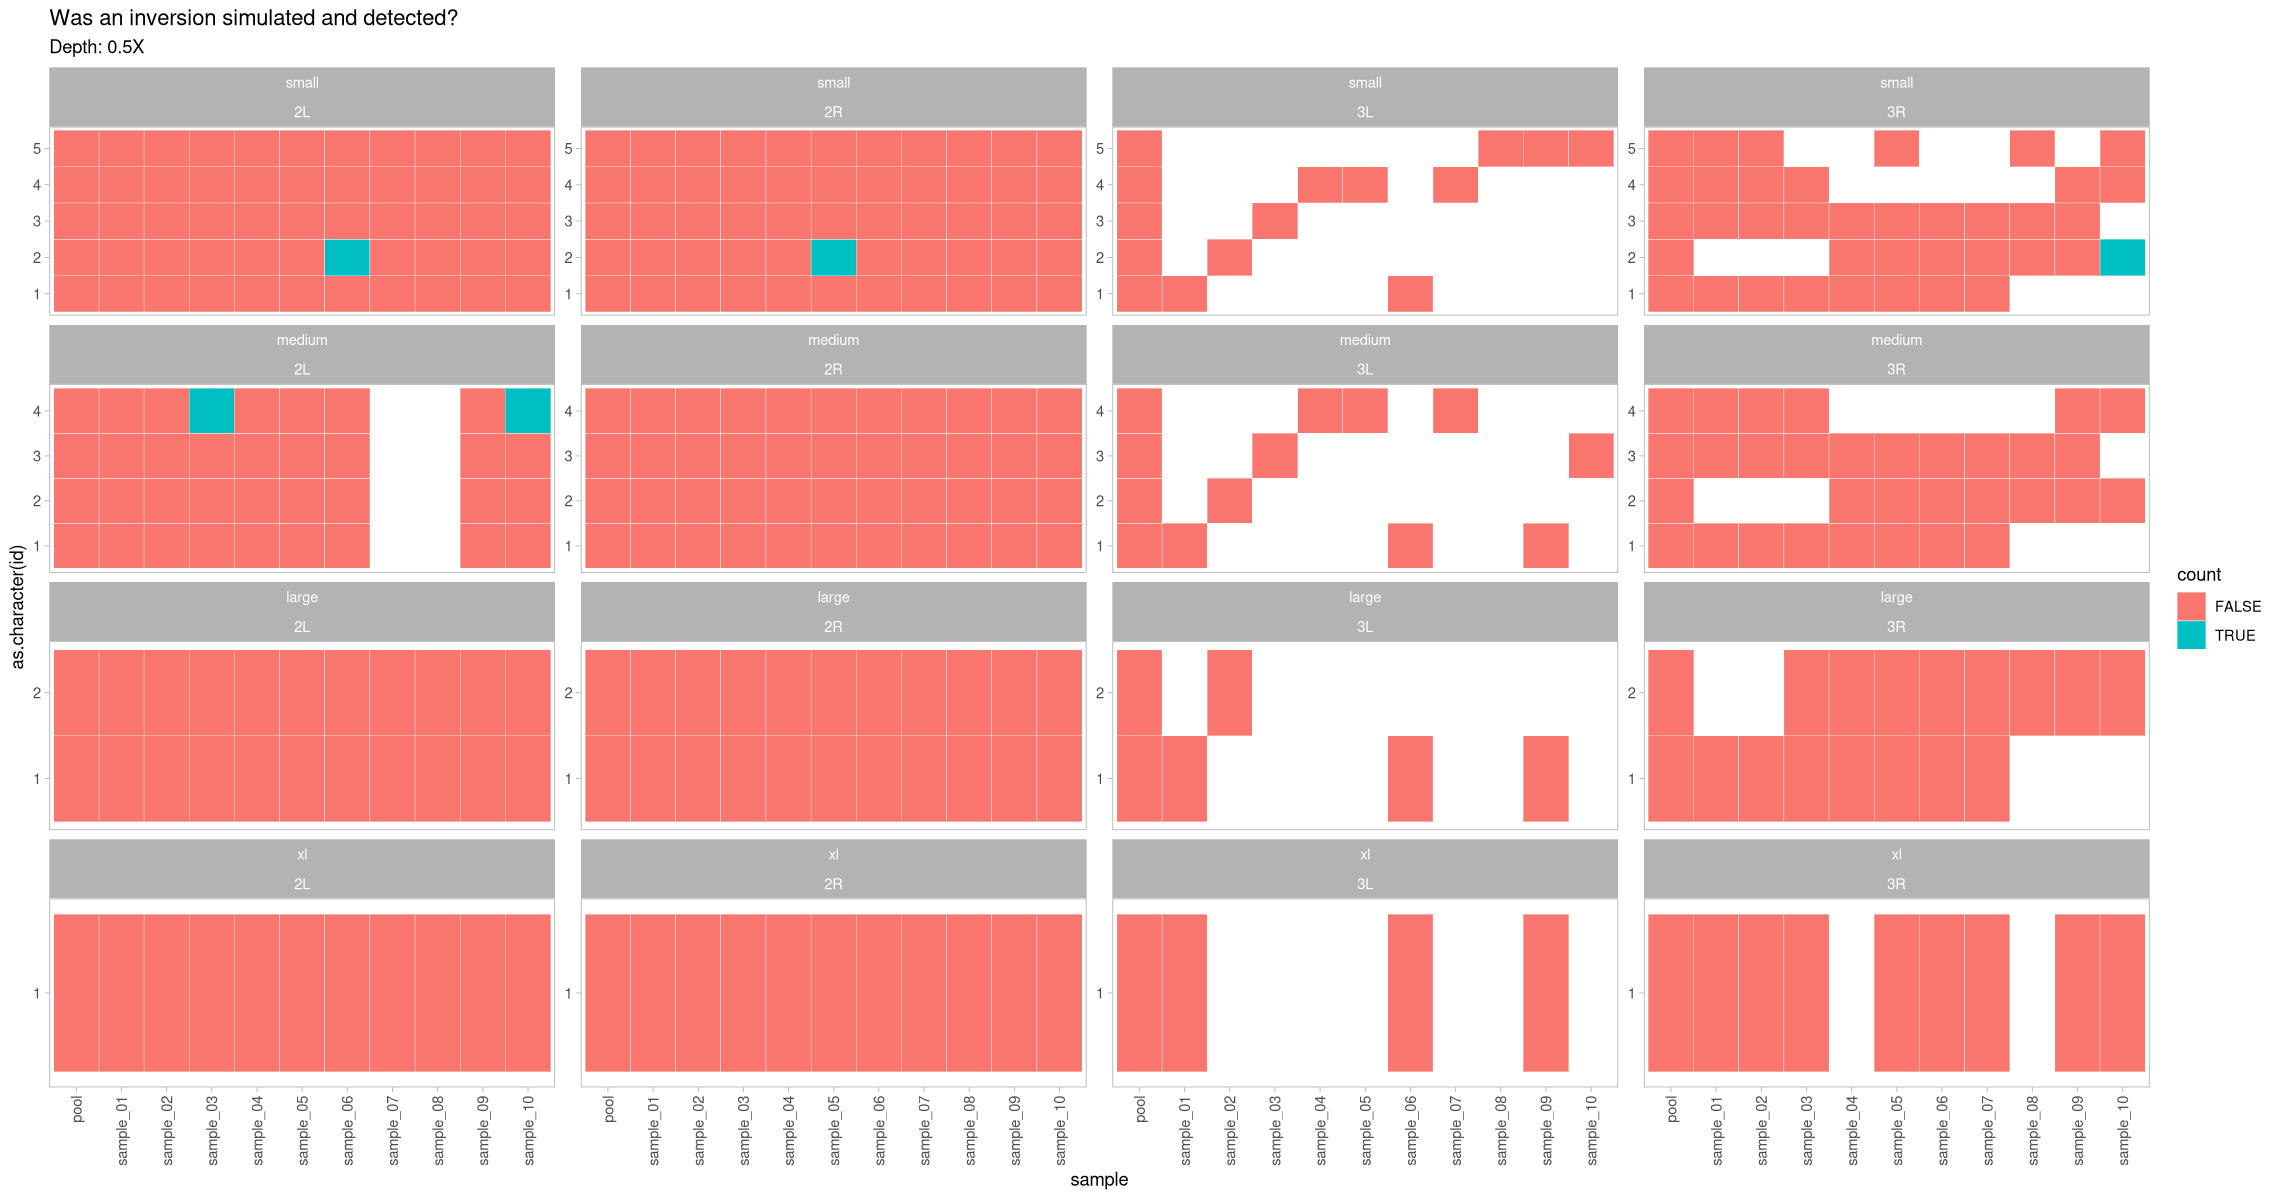

In [83]:
filter(assessment_present, depth == 0.5) %>%
ggplot(aes(x = sample, y = as.character(id), fill = count)) +
    geom_tile(color = "white") +
    theme_light() +
    labs(title = "Was an inversion simulated and detected?", subtitle = "Depth: 0.5X") +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_line(color = "black")
    ) +
    facet_wrap(size~contig,scales = "free_y")

### Depth 2X

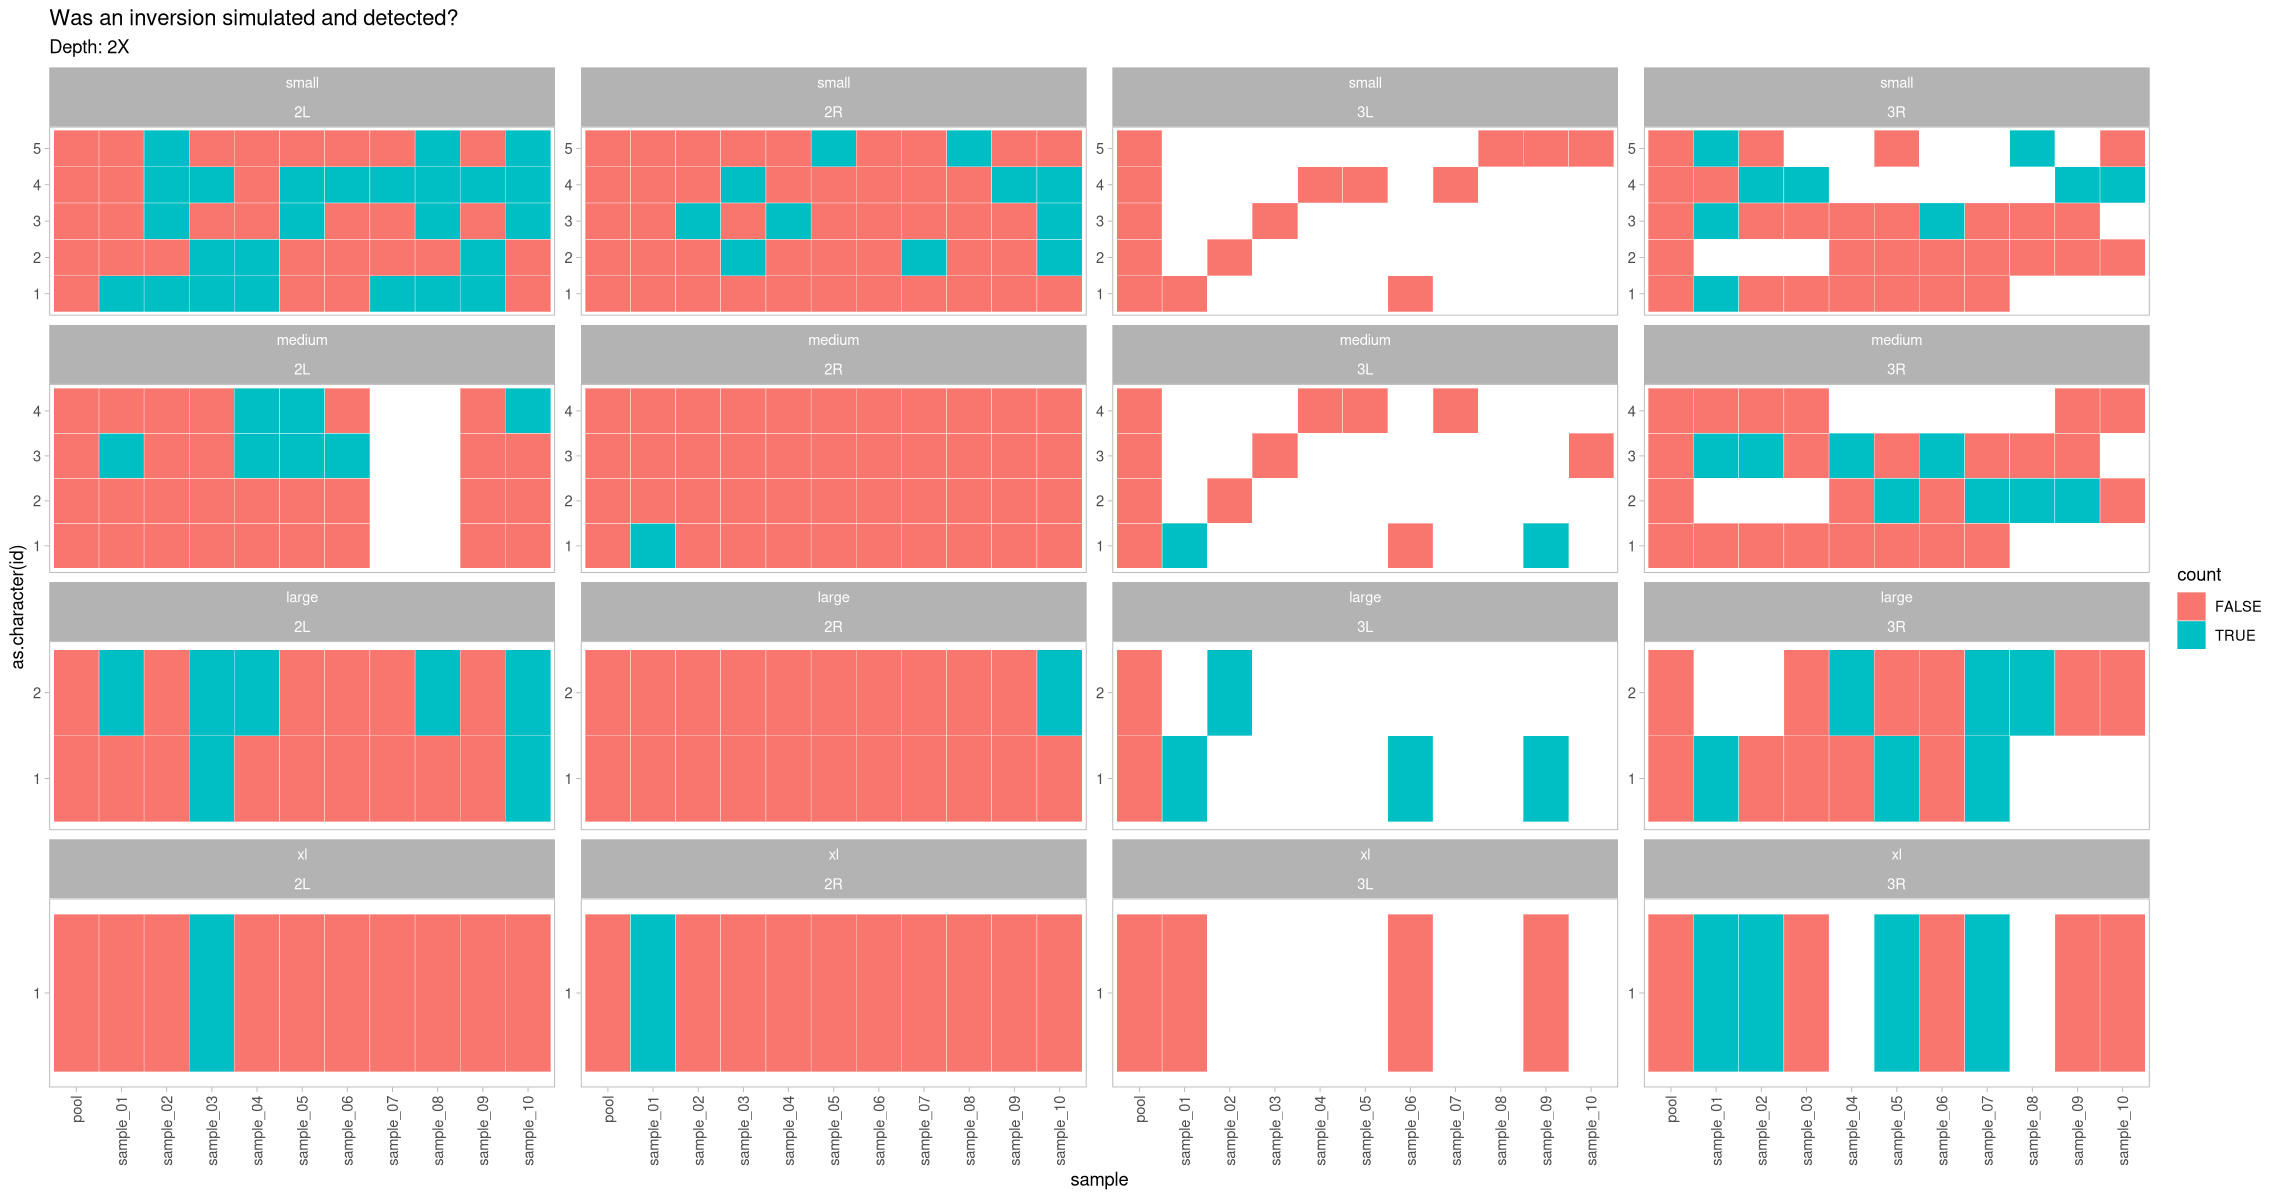

In [84]:
filter(assessment_present, depth == 2) %>%
ggplot(aes(x = sample, y = as.character(id), fill = count)) +
    geom_tile(color = "white") +
    theme_light() +
    labs(title = "Was an inversion simulated and detected?", subtitle = "Depth: 2X") +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_line(color = "black")
    ) +
    facet_wrap(size~contig,scales = "free_y")

### Depth 5X

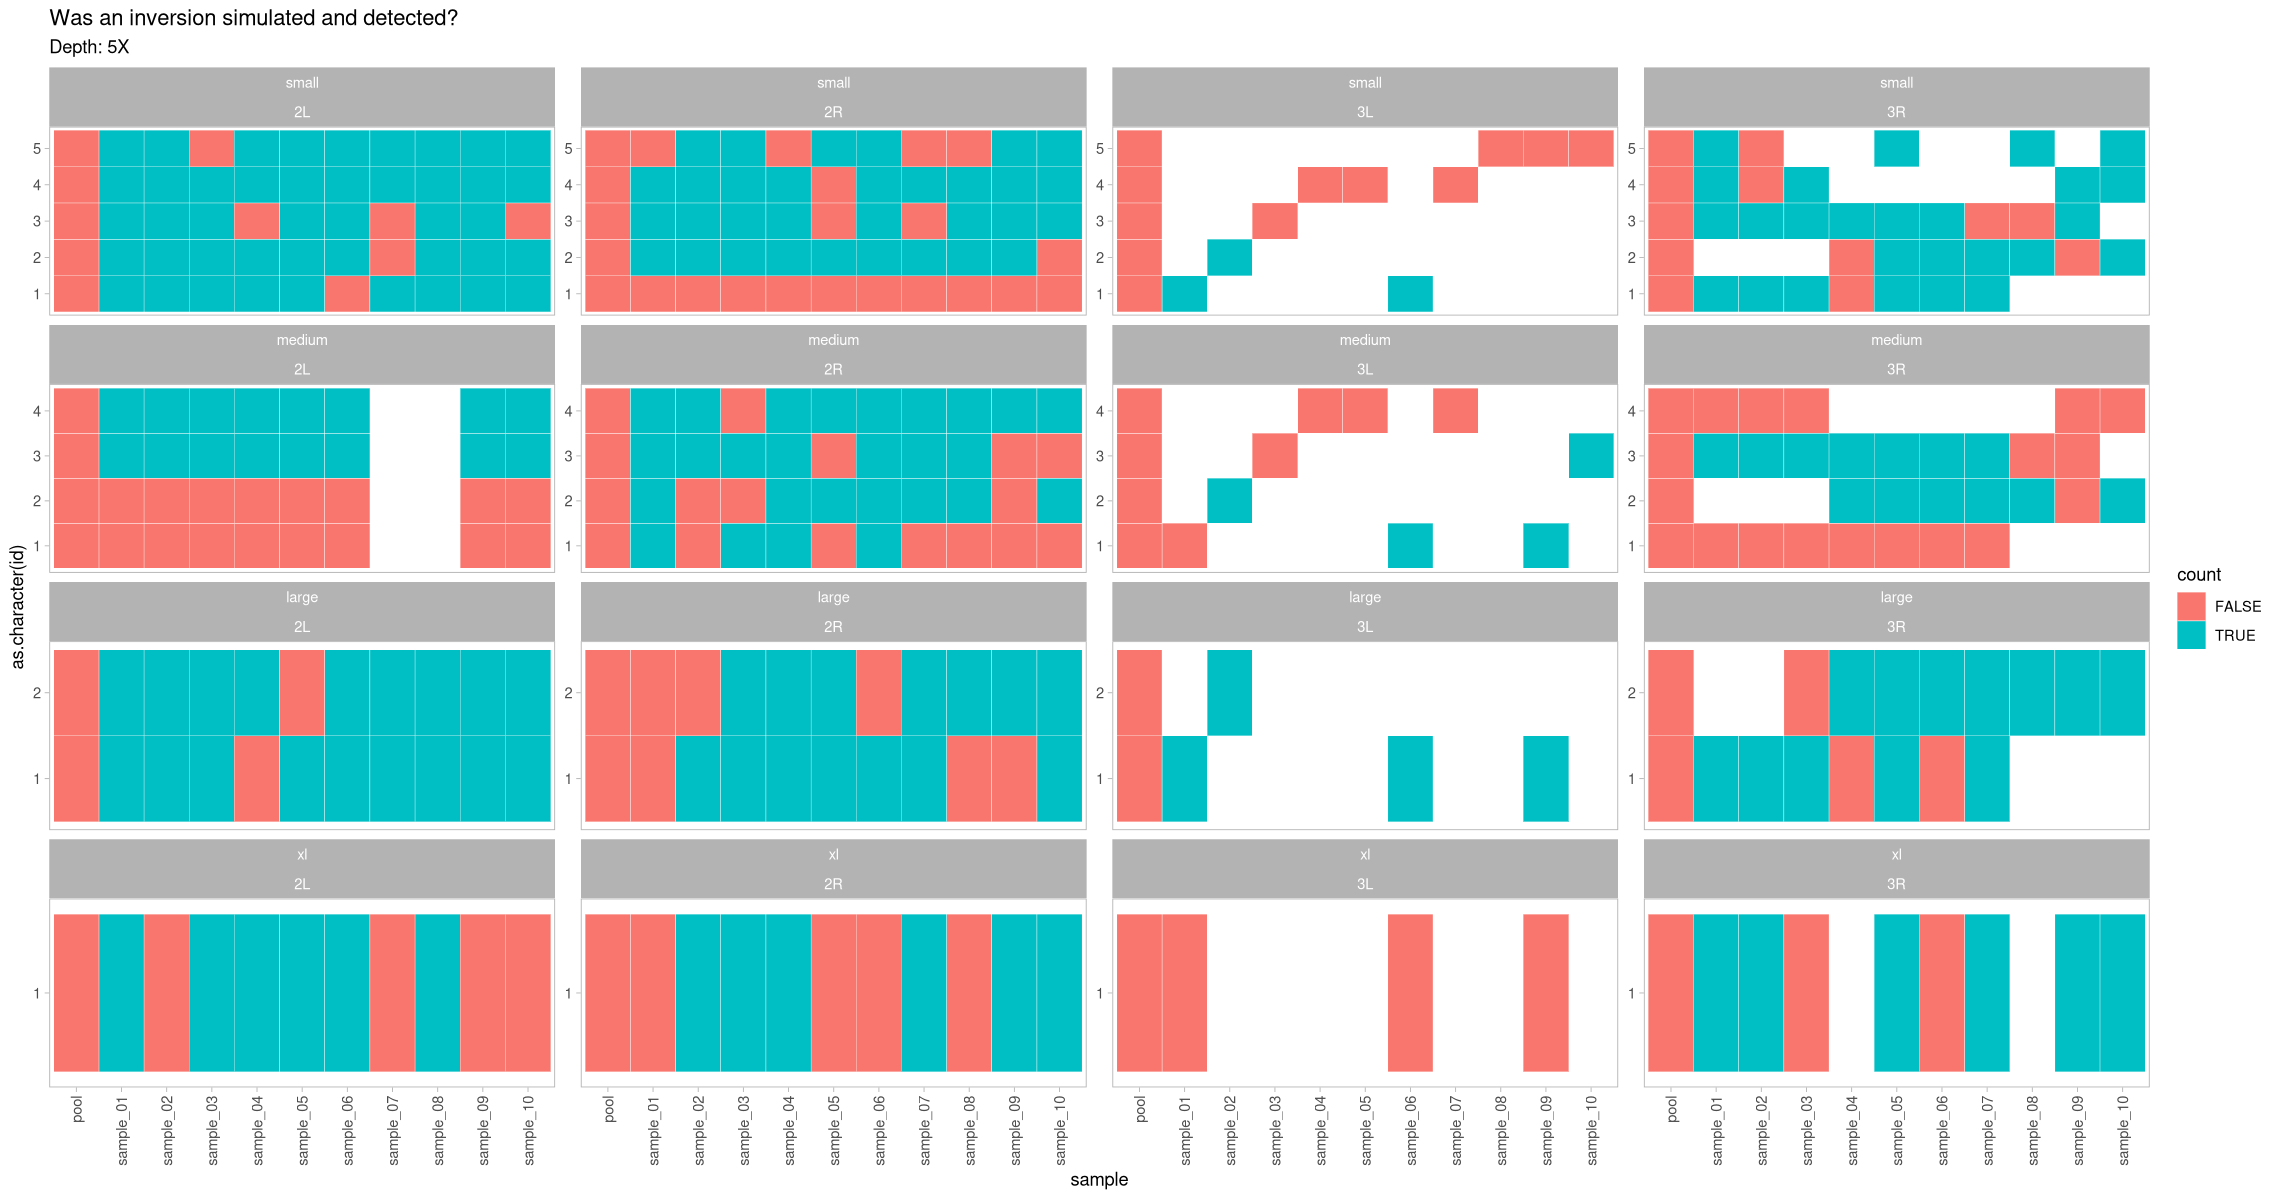

In [85]:
filter(assessment_present, depth == 5) %>%
ggplot(aes(x = sample, y = as.character(id), fill = count)) +
    geom_tile(color = "white") +
    theme_light() +
    labs(title = "Was an inversion simulated and detected?", subtitle = "Depth: 5X") +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_line(color = "black")
    ) +
    facet_wrap(size~contig,scales = "free_y")

### Depth 10X

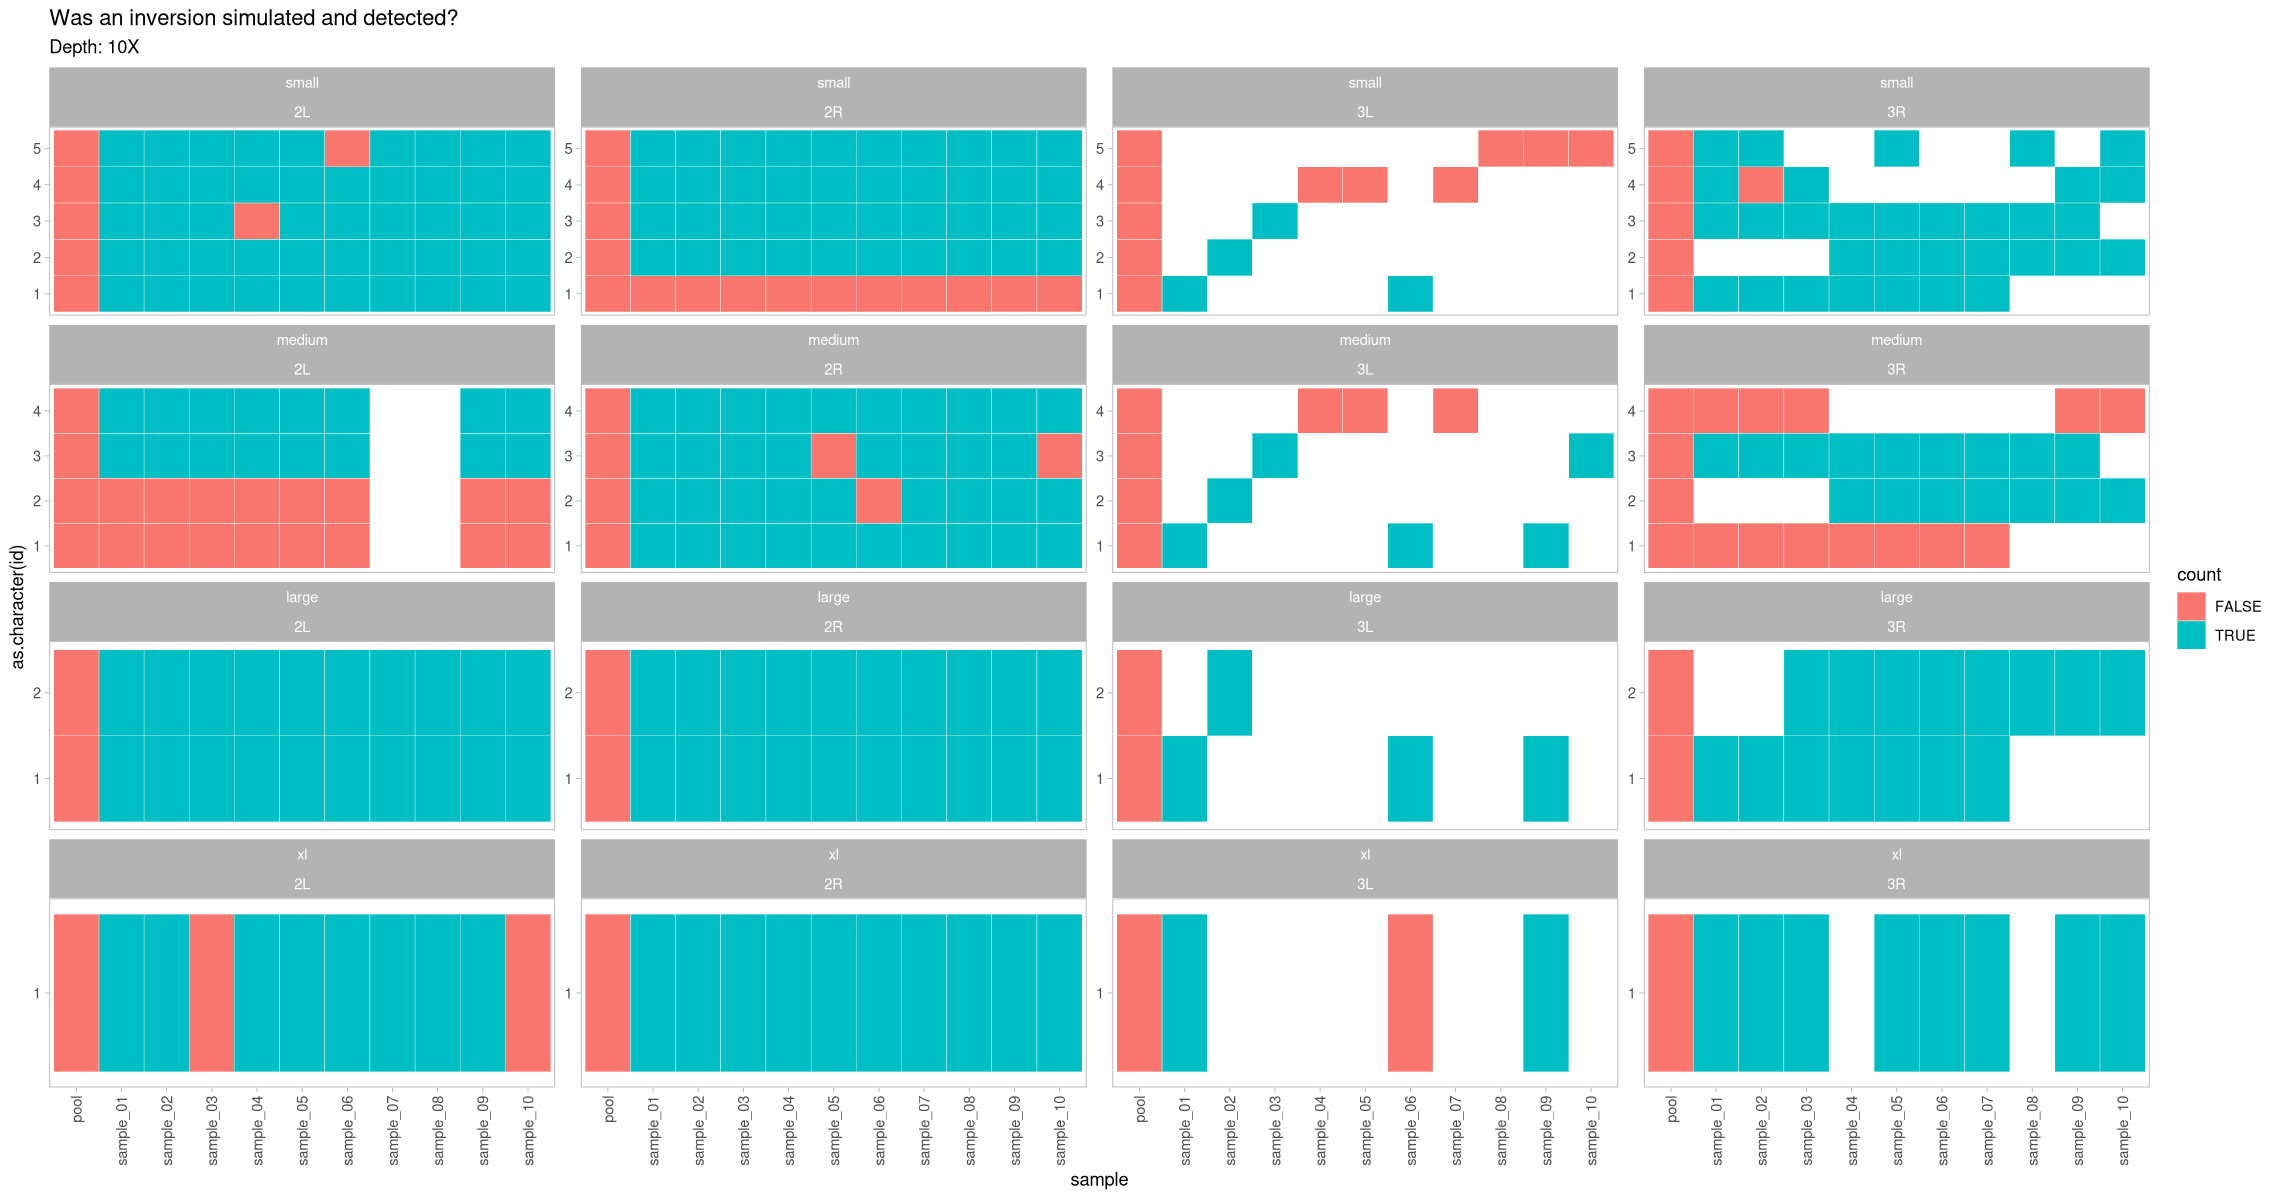

In [86]:
filter(assessment_present, depth == 10) %>%
ggplot(aes(x = sample, y = as.character(id), fill = count)) +
    geom_tile(color = "white") +
    theme_light() +
    labs(title = "Was an inversion simulated and detected?", subtitle = "Depth: 10X") +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_line(color = "black")
    ) +
    facet_wrap(size~contig,scales = "free_y")

### Depth 20X

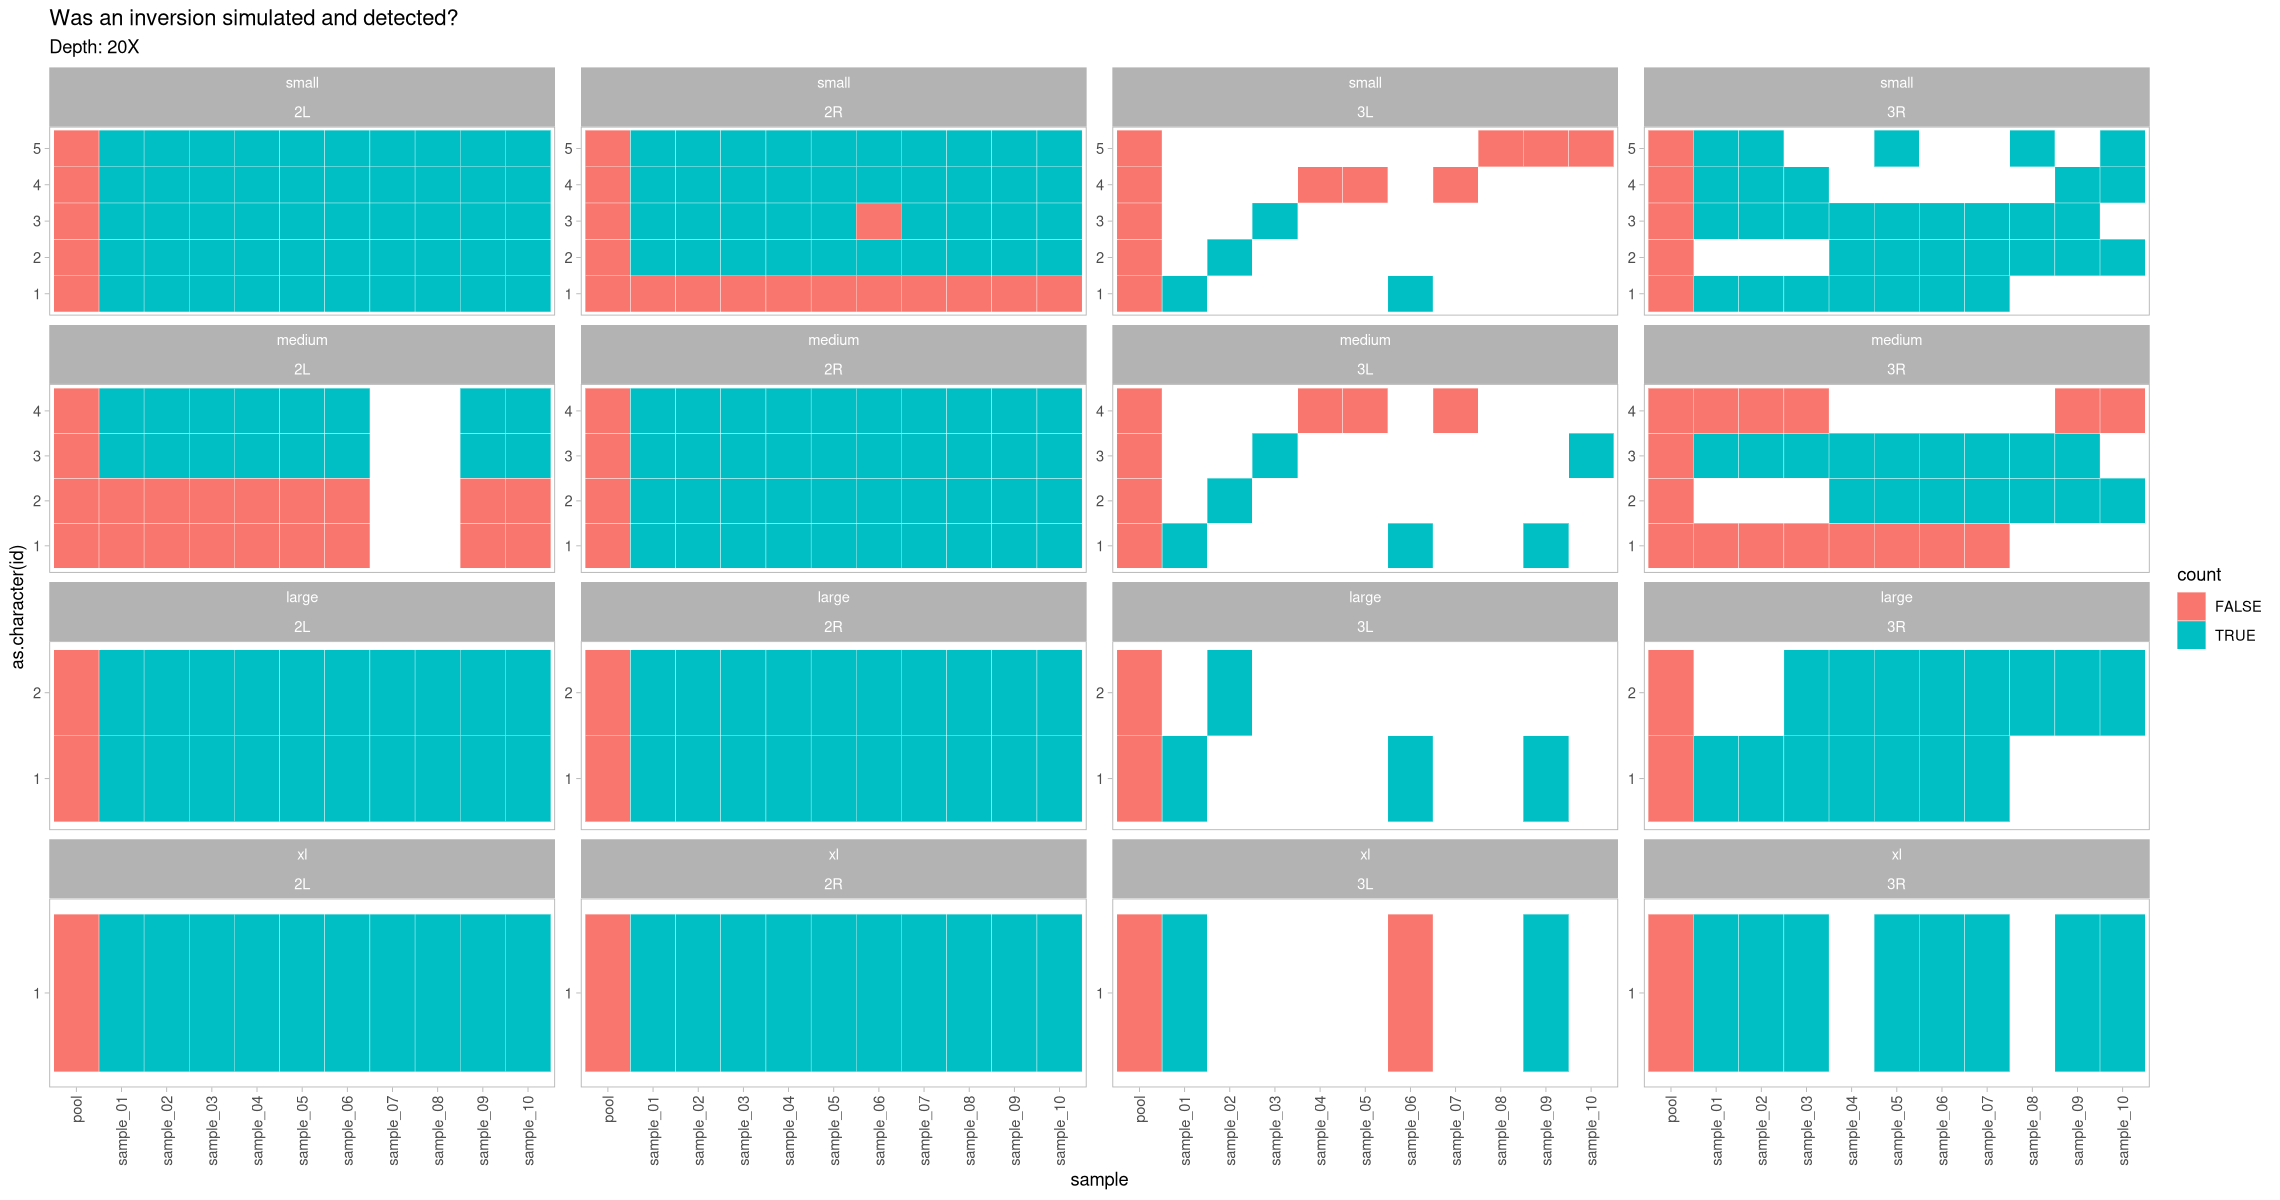

In [87]:
filter(assessment_present, depth == 20) %>%
ggplot(aes(x = sample, y = as.character(id), fill = count)) +
    geom_tile(color = "white") +
    theme_light() +
    labs(title = "Was an inversion simulated and detected?", subtitle = "Depth: 20X") +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_line(color = "black")
    ) +
    facet_wrap(size~contig,scales = "free_y")

This doesn't look right, the pooled samples definitely identified inversions, but these plots suggest they never did. This requires manual inspection.